In [1]:
!pip install -q mlflow imbalanced-learn xgboost shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 76.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 101.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132

In [4]:
import os
import json
import random
import warnings
from pathlib import Path

import joblib
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
)
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    make_scorer,
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

# MLflow tracking database and artifact directory for Google Colab
# MLflow tracking database and artifact directory for Google Colab
MLFLOW_DB_PATH = os.path.abspath("mlflow.db")
MLFLOW_ARTIFACT_PATH = os.path.abspath("mlartifacts")

os.makedirs(MLFLOW_ARTIFACT_PATH, exist_ok=True)

mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB_PATH}")

# Compatible across more MLflow versions
mlflow.set_experiment("AttriShield_Applied_ML")

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("MLflow experiment:", mlflow.get_experiment_by_name("AttriShield_Applied_ML").name)

2026/07/06 08:22:55 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/06 08:22:55 INFO mlflow.store.db.utils: Updating database tables
2026/07/06 08:22:57 INFO mlflow.tracking.fluent: Experiment with name 'AttriShield_Applied_ML' does not exist. Creating a new experiment.


MLflow tracking URI: sqlite:////content/mlflow.db
MLflow experiment: AttriShield_Applied_ML


In [5]:
from google.colab import files

uploaded = files.upload()
DATA_PATH = next(iter(uploaded))

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv


Dataset shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


,dtype,missing_values,missing_pct,unique_values,is_constant
EmployeeCount,int64,0,0.0,1,True
Over18,object,0,0.0,1,True
StandardHours,int64,0,0.0,1,True
Age,int64,0,0.0,43,False
Attrition,object,0,0.0,2,False
BusinessTravel,object,0,0.0,3,False
DailyRate,int64,0,0.0,886,False
Department,object,0,0.0,3,False
DistanceFromHome,int64,0,0.0,29,False
Education,int64,0,0.0,5,False


Duplicate rows: 0


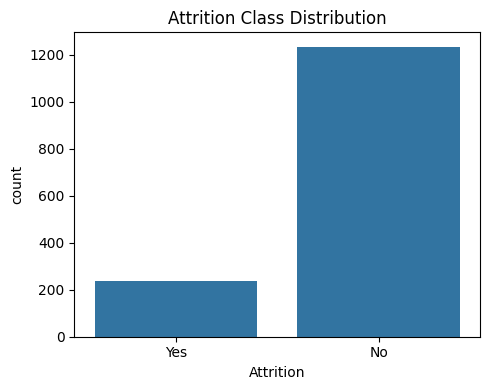

In [6]:
df_raw = pd.read_csv(DATA_PATH)

print("Dataset shape:", df_raw.shape)
display(df_raw.head())

audit = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing_values": df_raw.isna().sum(),
    "missing_pct": (df_raw.isna().mean() * 100).round(2),
    "unique_values": df_raw.nunique(),
    "is_constant": df_raw.nunique().eq(1),
})
display(audit.sort_values(["is_constant", "missing_values"], ascending=[False, False]))

print("Duplicate rows:", df_raw.duplicated().sum())

plt.figure(figsize=(5, 4))
sns.countplot(data=df_raw, x="Attrition")
plt.title("Attrition Class Distribution")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "class_distribution.png", dpi=150)
plt.show()

DROP_COLUMNS = [
    "EmployeeNumber",   # Identifier, not a meaningful predictor
    "EmployeeCount",    # Constant
    "Over18",           # Constant
    "StandardHours",    # Constant
]

df = df_raw.drop(columns=DROP_COLUMNS).copy()
df["Attrition"] = (df["Attrition"] == "Yes").astype(int)

X = df.drop(columns="Attrition")
y = df["Attrition"]

In [21]:
# ============================================================
# FEATURE ENGINEERING — HYPOTHESIS-DRIVEN, INTERPRETABLE FEATURES
# ============================================================

X = X.copy()

# 1. Compensation normalized by seniority level
X["IncomePerJobLevel"] = X["MonthlyIncome"] / X["JobLevel"].clip(lower=1)

# 2. Promotion stagnation relative to company tenure
X["PromotionStagnationRatio"] = (
    X["YearsSinceLastPromotion"] / (X["YearsAtCompany"] + 1)
)

# 3. Manager continuity relative to company tenure
X["ManagerTenureRatio"] = (
    X["YearsWithCurrManager"] / (X["YearsAtCompany"] + 1)
)

# 4. Time in current role relative to company tenure
X["RoleTenureRatio"] = (
    X["YearsInCurrentRole"] / (X["YearsAtCompany"] + 1)
)

# 5. Commute burden is potentially higher when overtime is present
X["OverTimeBinary"] = (X["OverTime"] == "Yes").astype(int)
X["CommuteOvertimeBurden"] = X["DistanceFromHome"] * X["OverTimeBinary"]

# 6. Early-tenure indicator
X["EarlyCareerFlag"] = (X["YearsAtCompany"] <= 2).astype(int)

print("Added engineered features:")
print([
    "IncomePerJobLevel",
    "PromotionStagnationRatio",
    "ManagerTenureRatio",
    "RoleTenureRatio",
    "CommuteOvertimeBurden",
    "EarlyCareerFlag",
])

Added engineered features:
['IncomePerJobLevel', 'PromotionStagnationRatio', 'ManagerTenureRatio', 'RoleTenureRatio', 'CommuteOvertimeBurden', 'EarlyCareerFlag']


In [35]:
# Raw OverTime is redundant after explicit overtime features are created.
X = X.drop(columns=["OverTime"])

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED,
)

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_transformer = SklearnPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = SklearnPipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    verbose_feature_names_out=False,
)

print("Train distribution:", y_train.value_counts().to_dict())
print("Test distribution:", y_test.value_counts().to_dict())

Train distribution: {0: 986, 1: 190}
Test distribution: {0: 247, 1: 47}


In [37]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}

models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=SEED,
    ),
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        max_depth=6,
        min_samples_leaf=8,
        random_state=SEED,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        min_samples_leaf=3,
        random_state=SEED,
        n_jobs=-1,
    ),
    "XGBoost": xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=SEED,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=2,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        n_jobs=-1,
    ),
}

benchmark_rows = []

for model_name, estimator in models.items():
    pipeline = ImbPipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("smote", SMOTE(random_state=SEED)),
        ("model", estimator),
    ])

    result = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
    )

    row = {"model": model_name}
    for metric in scoring:
        row[f"{metric}_mean"] = result[f"test_{metric}"].mean()
        row[f"{metric}_std"] = result[f"test_{metric}"].std()

    benchmark_rows.append(row)

    with mlflow.start_run(run_name=f"benchmark_{model_name.lower().replace(' ', '_')}"):
        mlflow.log_param("model_name", model_name)
        mlflow.log_param("cv_strategy", "Stratified 5-fold")
        mlflow.log_param("smote_inside_cv", True)
        mlflow.log_param("random_seed", SEED)

        mlflow.log_params({
            f"model__{key}": str(value)
            for key, value in estimator.get_params().items()
        })

        mlflow.log_metrics({
            f"cv_{metric}_mean": row[f"{metric}_mean"]
            for metric in scoring
        })

        mlflow.log_metrics({
            f"cv_{metric}_std": row[f"{metric}_std"]
            for metric in scoring
        })

benchmark_df = (
    pd.DataFrame(benchmark_rows)
    .sort_values(["pr_auc_mean", "recall_mean", "f1_mean"], ascending=False)
    .reset_index(drop=True)
)

display(benchmark_df)

benchmark_df.to_csv(
    ARTIFACT_DIR / "model_benchmark_5fold_cv.csv",
    index=False,
)

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
0,XGBoost,0.875849,0.007336,0.723728,0.063025,0.389474,0.078772,0.498753,0.058796,0.816203,0.031590,0.625005,0.062895
1,Logistic Regression,0.777176,0.022246,0.397734,0.029012,0.710526,0.072548,0.507490,0.022539,0.830910,0.022979,0.622735,0.067049
2,Random Forest,0.874998,0.016515,0.719899,0.065966,0.357895,0.129564,0.467363,0.126792,0.817221,0.030940,0.586585,0.073676
3,Decision Tree,0.789939,0.029226,0.363858,0.057200,0.373684,0.090244,0.362116,0.060388,0.669340,0.055977,0.325233,0.057616


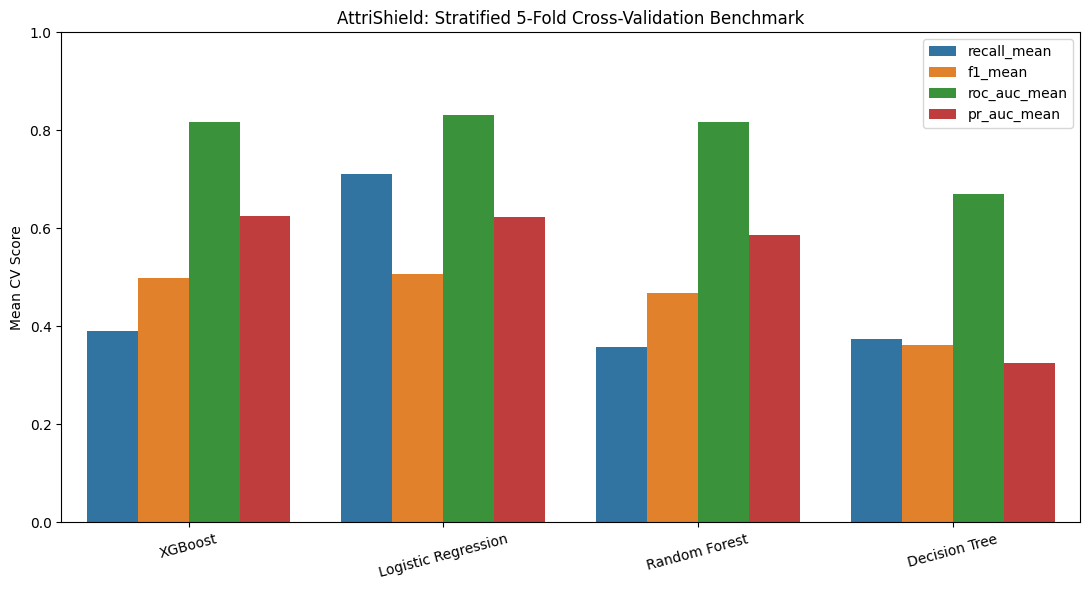

In [38]:
plot_df = benchmark_df.melt(
    id_vars="model",
    value_vars=["recall_mean", "f1_mean", "roc_auc_mean", "pr_auc_mean"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(11, 6))
sns.barplot(data=plot_df, x="model", y="score", hue="metric")
plt.ylim(0, 1)
plt.title("AttriShield: Stratified 5-Fold Cross-Validation Benchmark")
plt.xlabel("")
plt.ylabel("Mean CV Score")
plt.xticks(rotation=15)
plt.legend(title="")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "model_benchmark_5fold_cv.png", dpi=160)
plt.show()

In [39]:
# ============================================================
# 06 — FINAL XGBOOST + OUT-OF-FOLD THRESHOLD OPTIMIZATION
# ============================================================

from sklearn.base import clone
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow

final_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=SEED,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=2,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=1.0,
    n_jobs=-1,
)

# This pipeline is used only to generate honest out-of-fold probabilities.
oof_pipeline = ImbPipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("smote", SMOTE(random_state=SEED, k_neighbors=5)),
    ("model", clone(final_model)),
])

oof_proba = cross_val_predict(
    oof_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

# Business assumption:
# Missing an employee who will leave is estimated to cost 5x a false intervention.
FALSE_NEGATIVE_COST = 5
FALSE_POSITIVE_COST = 1

threshold_rows = []

for threshold in np.arange(0.10, 0.81, 0.05):
    oof_pred = (oof_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, oof_pred).ravel()

    threshold_rows.append({
        "threshold": round(float(threshold), 2),
        "precision": precision_score(y_train, oof_pred, zero_division=0),
        "recall": recall_score(y_train, oof_pred, zero_division=0),
        "f1": f1_score(y_train, oof_pred, zero_division=0),
        "false_positives": fp,
        "false_negatives": fn,
        "business_cost": (FALSE_POSITIVE_COST * fp) + (FALSE_NEGATIVE_COST * fn),
    })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df = threshold_df.sort_values("business_cost").reset_index(drop=True)

display(threshold_df.style.format({
    "precision": "{:.3f}",
    "recall": "{:.3f}",
    "f1": "{:.3f}",
}))

BEST_THRESHOLD = float(threshold_df.loc[0, "threshold"])
print(f"Selected threshold: {BEST_THRESHOLD:.2f}")

,threshold,precision,recall,f1,false_positives,false_negatives,business_cost
0,0.150000,0.439,0.705,0.541,171,56,451
1,0.200000,0.484,0.653,0.556,132,66,462
2,0.100000,0.362,0.742,0.486,249,49,494
3,0.250000,0.530,0.563,0.546,95,83,510
4,0.300000,0.570,0.537,0.553,77,88,517
5,0.350000,0.623,0.495,0.551,57,96,537
6,0.400000,0.642,0.453,0.531,48,104,568
7,0.450000,0.664,0.416,0.511,40,111,595
8,0.500000,0.712,0.389,0.503,30,116,610
9,0.550000,0.773,0.358,0.489,20,122,630


Selected threshold: 0.15


In [40]:
# ============================================================
# 08 — FINAL TRAINING + UNTOUCHED TEST-SET EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.base import clone
import joblib
import mlflow

final_pipeline = ImbPipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("smote", SMOTE(random_state=SEED, k_neighbors=5)),
    ("model", clone(final_model)),
])

# Fits preprocessing and SMOTE only on X_train / y_train.
final_pipeline.fit(X_train, y_train)

# Final evaluation: X_test has not been used for model selection or threshold selection.
test_proba = final_pipeline.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= BEST_THRESHOLD).astype(int)

final_metrics = {
    "accuracy": accuracy_score(y_test, test_pred),
    "precision": precision_score(y_test, test_pred, zero_division=0),
    "recall": recall_score(y_test, test_pred, zero_division=0),
    "f1": f1_score(y_test, test_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, test_proba),
    "pr_auc": average_precision_score(y_test, test_proba),
}

print(f"Final decision threshold: {BEST_THRESHOLD:.2f}\n")

print("Final untouched-test metrics:")
for metric, value in final_metrics.items():
    print(f"{metric:>10}: {value:.4f}")

print("\nClassification report:")
print(classification_report(y_test, test_pred, target_names=["Stay", "Leave"]))

tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()
print(f"\nConfusion matrix counts: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

# Save full pipeline: preprocessing + SMOTE setup + trained XGBoost model.
MODEL_PATH = "attrishield_pipeline.joblib"
joblib.dump(final_pipeline, MODEL_PATH)
print(f"\nSaved model pipeline: {MODEL_PATH}")

Final decision threshold: 0.15

Final untouched-test metrics:
  accuracy: 0.7789
 precision: 0.3846
    recall: 0.6383
        f1: 0.4800
   roc_auc: 0.8058
    pr_auc: 0.5440

Classification report:
              precision    recall  f1-score   support

        Stay       0.92      0.81      0.86       247
       Leave       0.38      0.64      0.48        47

    accuracy                           0.78       294
   macro avg       0.65      0.72      0.67       294
weighted avg       0.84      0.78      0.80       294


Confusion matrix counts: TN=199, FP=48, FN=17, TP=30

Saved model pipeline: attrishield_pipeline.joblib


Brier score: 0.1049  (lower is better)
Expected Calibration Error: 0.0564  (lower is better)


,bin,n_samples,mean_predicted_risk,observed_attrition_rate,absolute_gap
0,0,199,0.035269,0.055276,0.020007
1,1,28,0.138714,0.357143,0.218429
2,2,19,0.247912,0.263158,0.015246
3,3,19,0.339990,0.210526,0.129464
4,4,8,0.446761,0.375000,0.071761
5,5,6,0.545702,0.333333,0.212368
6,6,2,0.658637,0.500000,0.158637
7,7,4,0.760854,0.750000,0.010854
8,8,4,0.822146,1.000000,0.177854
9,9,5,0.961319,0.800000,0.161319


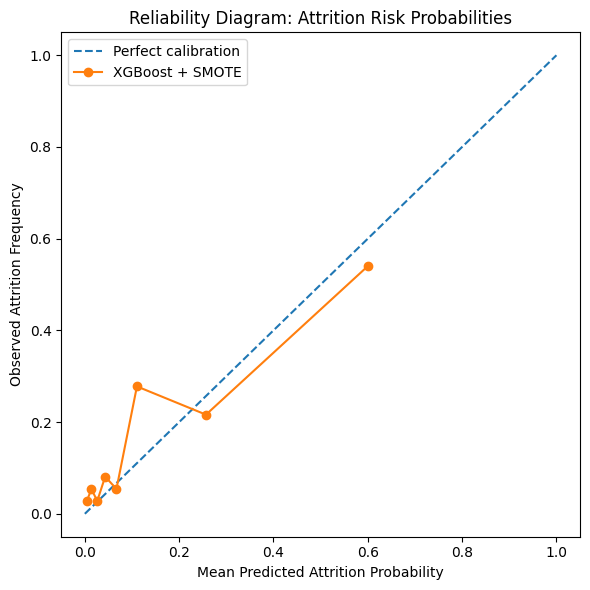

In [41]:
# ============================================================
# 10 — CALIBRATION: BRIER SCORE, ECE, RELIABILITY DIAGRAM
# ============================================================

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import numpy as np
import matplotlib.pyplot as plt
import json
import mlflow

def expected_calibration_error(y_true, probabilities, n_bins=10):
    """
    Expected Calibration Error (ECE).
    Lower is better; 0 means perfectly calibrated probabilities.
    """
    y_true = np.asarray(y_true)
    probabilities = np.asarray(probabilities)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(probabilities, bin_edges[1:-1], right=True)

    ece = 0.0
    calibration_rows = []

    for bin_id in range(n_bins):
        mask = bin_ids == bin_id

        if mask.sum() == 0:
            continue

        mean_confidence = probabilities[mask].mean()
        observed_frequency = y_true[mask].mean()
        bin_fraction = mask.mean()

        ece += bin_fraction * abs(observed_frequency - mean_confidence)

        calibration_rows.append({
            "bin": bin_id,
            "n_samples": int(mask.sum()),
            "mean_predicted_risk": float(mean_confidence),
            "observed_attrition_rate": float(observed_frequency),
            "absolute_gap": float(abs(observed_frequency - mean_confidence)),
        })

    return float(ece), pd.DataFrame(calibration_rows)

brier = brier_score_loss(y_test, test_proba)
ece, calibration_table = expected_calibration_error(y_test, test_proba, n_bins=10)

print(f"Brier score: {brier:.4f}  (lower is better)")
print(f"Expected Calibration Error: {ece:.4f}  (lower is better)")

display(calibration_table)

calibration_table_path = ARTIFACT_DIR / "calibration_bins.csv"
calibration_table.to_csv(calibration_table_path, index=False)

fraction_positive, mean_predicted_value = calibration_curve(
    y_test,
    test_proba,
    n_bins=8,
    strategy="quantile",
)

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.plot(
    mean_predicted_value,
    fraction_positive,
    marker="o",
    label="XGBoost + SMOTE",
)
plt.title("Reliability Diagram: Attrition Risk Probabilities")
plt.xlabel("Mean Predicted Attrition Probability")
plt.ylabel("Observed Attrition Frequency")
plt.legend()
plt.tight_layout()

calibration_plot_path = ARTIFACT_DIR / "calibration_curve.png"
plt.savefig(calibration_plot_path, dpi=160)
plt.show()

with mlflow.start_run(run_name="xgboost_calibration_analysis"):
    mlflow.log_params({
        "model_name": "XGBoost",
        "calibration_dataset": "untouched test set",
        "ece_bins": 10,
        "reliability_bins": 8,
    })
    mlflow.log_metrics({
        "brier_score": brier,
        "expected_calibration_error": ece,
    })
    mlflow.log_artifact(str(calibration_table_path))
    mlflow.log_artifact(str(calibration_plot_path))

with open(ARTIFACT_DIR / "calibration_metrics.json", "w") as file:
    json.dump(
        {
            "brier_score": brier,
            "expected_calibration_error": ece,
        },
        file,
        indent=2,
    )

In [42]:
# ============================================================
# 11 — SHAP: GLOBAL FEATURE IMPORTANCE + INDIVIDUAL EXPLANATION
# ============================================================

import shap
import pandas as pd
import matplotlib.pyplot as plt
import mlflow

# Get fitted components from the final pipeline.
fitted_preprocessor = final_pipeline.named_steps["preprocessor"]
fitted_xgb_model = final_pipeline.named_steps["model"]

# Transform raw data using the fitted preprocessor.
# Do not apply SMOTE here: explain real employee records, not synthetic examples.
X_train_transformed = fitted_preprocessor.transform(X_train)
X_test_transformed = fitted_preprocessor.transform(X_test)

feature_names = fitted_preprocessor.get_feature_names_out()

X_train_shap = pd.DataFrame(
    X_train_transformed,
    columns=feature_names,
    index=X_train.index,
)

X_test_shap = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index,
)

# TreeExplainer is efficient for XGBoost.
explainer = shap.TreeExplainer(fitted_xgb_model)
shap_values = explainer(X_test_shap)

print("SHAP values shape:", shap_values.values.shape)
print("Explained test records:", len(X_test_shap))

SHAP values shape: (294, 56)
Explained test records: 294


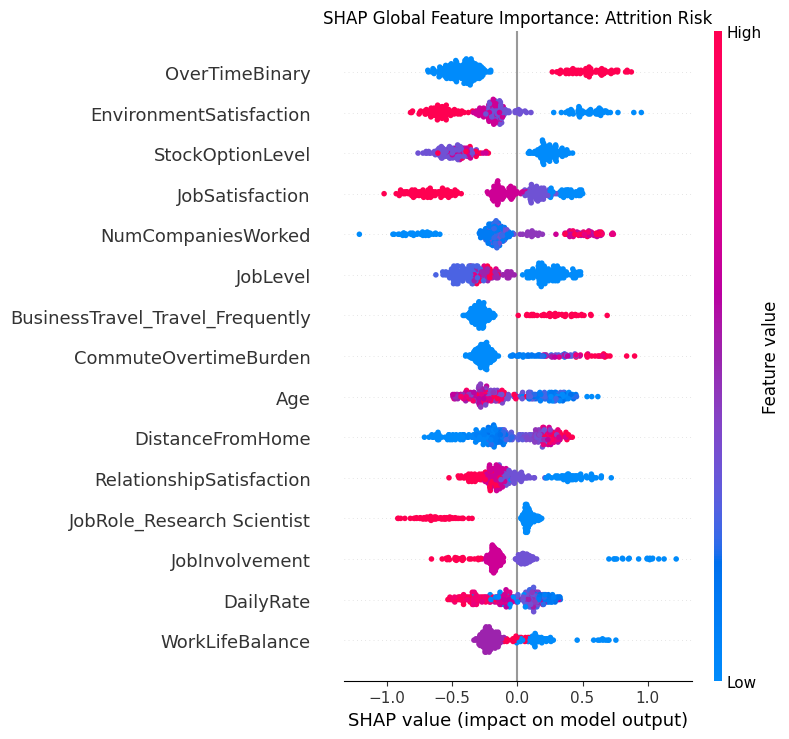

,feature,mean_abs_shap
0,OverTimeBinary,0.452866
1,EnvironmentSatisfaction,0.380419
2,StockOptionLevel,0.375104
3,JobSatisfaction,0.346852
4,NumCompaniesWorked,0.316331
5,JobLevel,0.296340
6,BusinessTravel_Travel_Frequently,0.292252
7,CommuteOvertimeBurden,0.279920
8,Age,0.253498
9,DistanceFromHome,0.247842


In [43]:
# ============================================================
# 12 — SHAP GLOBAL SUMMARY + TOP-FEATURE TABLE
# ============================================================

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values.values,
    X_test_shap,
    feature_names=feature_names,
    show=False,
    max_display=15,
)
plt.title("SHAP Global Feature Importance: Attrition Risk")
plt.tight_layout()

shap_summary_path = ARTIFACT_DIR / "shap_summary.png"
plt.savefig(shap_summary_path, dpi=160, bbox_inches="tight")
plt.show()

mean_abs_shap = (
    pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": np.abs(shap_values.values).mean(axis=0),
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

display(mean_abs_shap.head(15))

shap_importance_path = ARTIFACT_DIR / "shap_global_importance.csv"
mean_abs_shap.to_csv(shap_importance_path, index=False)

with mlflow.start_run(run_name="xgboost_shap_global_explainability"):
    mlflow.log_param("explanation_dataset", "untouched test set")
    mlflow.log_param("explainer", "shap.TreeExplainer")
    mlflow.log_artifact(str(shap_summary_path))
    mlflow.log_artifact(str(shap_importance_path))

Selected test employee index: 911
Predicted attrition probability: 0.987
Prediction at threshold 0.15: ATTRITION RISK


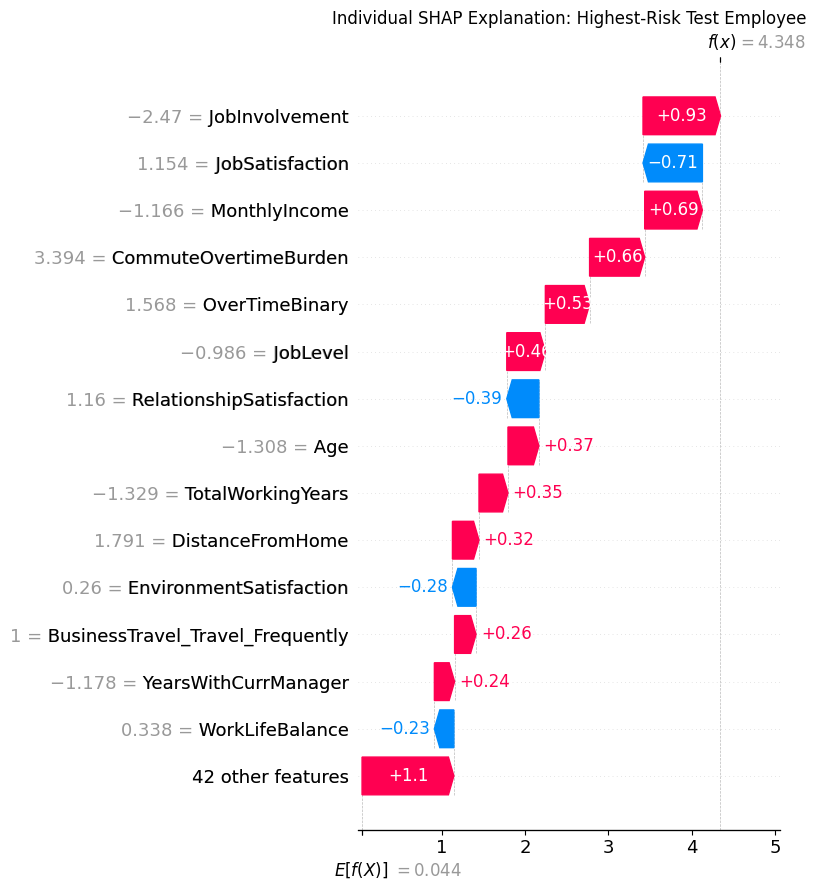

In [44]:
# ============================================================
# 13 — SHAP WATERFALL: ONE HIGH-RISK EMPLOYEE
# ============================================================

highest_risk_position = int(np.argmax(test_proba))
highest_risk_index = X_test_shap.index[highest_risk_position]

print("Selected test employee index:", highest_risk_index)
print(f"Predicted attrition probability: {test_proba[highest_risk_position]:.3f}")
print(f"Prediction at threshold {BEST_THRESHOLD:.2f}:",
      "ATTRITION RISK" if test_pred[highest_risk_position] == 1 else "RETENTION")

plt.figure(figsize=(10, 7))
shap.plots.waterfall(
    shap_values[highest_risk_position],
    max_display=15,
    show=False,
)
plt.title("Individual SHAP Explanation: Highest-Risk Test Employee")
plt.tight_layout()

waterfall_path = ARTIFACT_DIR / "shap_waterfall_high_risk_employee.png"
plt.savefig(waterfall_path, dpi=160, bbox_inches="tight")
plt.show()

# Save the raw employee profile separately for transparent review.
employee_profile = X_test.loc[[highest_risk_index]].copy()
employee_profile["predicted_attrition_probability"] = test_proba[highest_risk_position]
employee_profile["decision_threshold"] = BEST_THRESHOLD
employee_profile["predicted_attrition"] = test_pred[highest_risk_position]

employee_profile_path = ARTIFACT_DIR / "high_risk_employee_profile.csv"
employee_profile.to_csv(employee_profile_path, index=False)

with mlflow.start_run(run_name="xgboost_shap_individual_explanation"):
    mlflow.log_params({
        "employee_source": "highest-risk untouched test example",
        "test_row_index": int(highest_risk_index),
        "decision_threshold": BEST_THRESHOLD,
    })
    mlflow.log_metric(
        "predicted_attrition_probability",
        float(test_proba[highest_risk_position]),
    )
    mlflow.log_artifact(str(waterfall_path))
    mlflow.log_artifact(str(employee_profile_path))

,outcome_group,count
0,True Negative,199
1,False Positive,48
2,False Negative,17
3,True Positive,30


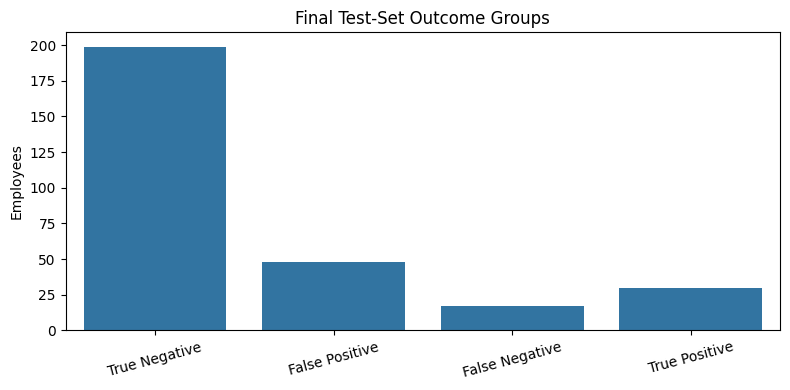

False positives: 48
False negatives: 17


,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,PromotionStagnationRatio,ManagerTenureRatio,RoleTenureRatio,OverTimeBinary,CommuteOvertimeBurden,EarlyCareerFlag,actual_attrition,predicted_probability,predicted_attrition,outcome_group
1111,53,Travel_Rarely,607,Research & Development,2,5,Technical Degree,3,Female,78,...,0.029412,0.264706,0.205882,0,0,0,1,0.004736,0,False Negative
126,58,Travel_Rarely,147,Research & Development,23,4,Medical,4,Female,94,...,0.365854,0.146341,0.243902,0,0,0,1,0.013504,0,False Negative
45,41,Travel_Rarely,1360,Research & Development,12,3,Technical Degree,2,Female,49,...,0.652174,0.347826,0.652174,0,0,0,1,0.014468,0,False Negative
217,29,Travel_Rarely,992,Research & Development,1,3,Technical Degree,3,Male,85,...,0.142857,0.714286,0.285714,0,0,0,1,0.023524,0,False Negative
789,44,Travel_Rarely,1376,Human Resources,1,2,Medical,2,Male,91,...,0.142857,0.285714,0.285714,0,0,0,1,0.035129,0,False Negative
562,33,Travel_Rarely,527,Research & Development,1,4,Other,4,Male,63,...,0.636364,0.727273,0.818182,1,1,0,1,0.040789,0,False Negative
136,51,Travel_Frequently,1150,Research & Development,8,4,Life Sciences,1,Male,53,...,0.000000,0.600000,0.400000,0,0,0,1,0.043678,0,False Negative
24,34,Travel_Rarely,699,Research & Development,6,1,Medical,2,Male,83,...,0.200000,0.600000,0.400000,0,0,0,1,0.058393,0,False Negative
382,26,Travel_Frequently,575,Research & Development,3,1,Technical Degree,3,Male,73,...,0.000000,0.571429,0.571429,0,0,0,1,0.061174,0,False Negative
780,28,Non-Travel,1366,Research & Development,24,2,Technical Degree,2,Male,72,...,0.090909,0.818182,0.636364,0,0,0,1,0.084768,0,False Negative


In [45]:
# ============================================================
# 14 — STRUCTURED ERROR ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow

# Preserve raw, human-readable employee features for review.
error_analysis_df = X_test.copy()
error_analysis_df["actual_attrition"] = y_test.values
error_analysis_df["predicted_probability"] = test_proba
error_analysis_df["predicted_attrition"] = test_pred

# Four outcome categories
conditions = [
    (error_analysis_df["actual_attrition"] == 0) & (error_analysis_df["predicted_attrition"] == 0),
    (error_analysis_df["actual_attrition"] == 0) & (error_analysis_df["predicted_attrition"] == 1),
    (error_analysis_df["actual_attrition"] == 1) & (error_analysis_df["predicted_attrition"] == 0),
    (error_analysis_df["actual_attrition"] == 1) & (error_analysis_df["predicted_attrition"] == 1),
]

labels = ["True Negative", "False Positive", "False Negative", "True Positive"]

error_analysis_df["outcome_group"] = np.select(
    conditions,
    labels,
    default="Unknown",
)

outcome_summary = (
    error_analysis_df["outcome_group"]
    .value_counts()
    .reindex(labels, fill_value=0)
    .rename_axis("outcome_group")
    .reset_index(name="count")
)

display(outcome_summary)

plt.figure(figsize=(8, 4))
sns.barplot(data=outcome_summary, x="outcome_group", y="count")
plt.title("Final Test-Set Outcome Groups")
plt.xlabel("")
plt.ylabel("Employees")
plt.xticks(rotation=15)
plt.tight_layout()

outcome_plot_path = ARTIFACT_DIR / "error_outcome_groups.png"
plt.savefig(outcome_plot_path, dpi=160)
plt.show()

error_analysis_path = ARTIFACT_DIR / "error_analysis_all_test_cases.csv"
error_analysis_df.to_csv(error_analysis_path, index=False)

false_positive_df = error_analysis_df.query("outcome_group == 'False Positive'").copy()
false_negative_df = error_analysis_df.query("outcome_group == 'False Negative'").copy()

false_positive_path = ARTIFACT_DIR / "false_positives.csv"
false_negative_path = ARTIFACT_DIR / "false_negatives.csv"

false_positive_df.to_csv(false_positive_path, index=False)
false_negative_df.to_csv(false_negative_path, index=False)

print(f"False positives: {len(false_positive_df)}")
print(f"False negatives: {len(false_negative_df)}")
display(false_negative_df.sort_values("predicted_probability").head(10))

In [46]:
# ============================================================
# 15 — FAILURE TAXONOMY: FALSE NEGATIVES VS TRUE POSITIVES
# ============================================================

comparison_features = [
    "Age",
    "MonthlyIncome",
    "DistanceFromHome",
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "WorkLifeBalance",
    "YearsAtCompany",
    "YearsWithCurrManager",
    "NumCompaniesWorked",
]

available_features = [
    feature for feature in comparison_features
    if feature in error_analysis_df.columns
]

segment_summary = (
    error_analysis_df[
        error_analysis_df["outcome_group"].isin(["False Negative", "True Positive"])
    ]
    .groupby("outcome_group")[available_features]
    .agg(["mean", "median", "count"])
    .round(2)
)

display(segment_summary)

segment_summary_path = ARTIFACT_DIR / "false_negative_vs_true_positive_summary.csv"
segment_summary.to_csv(segment_summary_path)

# Categorical segment view
categorical_segments = ["OverTime", "BusinessTravel", "Department", "JobRole"]

for feature in categorical_segments:
    if feature not in error_analysis_df.columns:
        continue

    segment_table = pd.crosstab(
        error_analysis_df["outcome_group"],
        error_analysis_df[feature],
        normalize="index",
    ).round(3)

    print(f"\nOutcome distribution by {feature}")
    display(segment_table)

    safe_name = feature.replace(" ", "_").lower()
    segment_table.to_csv(
        ARTIFACT_DIR / f"error_analysis_by_{safe_name}.csv"
    )

Age              MonthlyIncome                \
                 mean median count          mean  median count   
outcome_group                                                    
False Negative  37.41   33.0    17       6385.06  4787.0    17   
True Positive   34.50   33.0    30       3521.93  2721.0    30   

               DistanceFromHome              JobSatisfaction  ...  \
                           mean median count            mean  ...   
outcome_group                                                 ...   
False Negative             8.65    6.0    17            2.88  ...   
True Positive              9.60    9.0    30            2.30  ...   

               WorkLifeBalance YearsAtCompany               \
                         count           mean median count   
outcome_group                                                
False Negative              17          10.88    6.0    17   
True Positive               30           3.33    3.0    30   

               YearsWithCurrManager              NumCompaniesWorked         \
                               mean median count               mean median   
outcome_group                                                                
False Negative                 4.82    5.0    17               2.29    1.0   
True Positive                  1.90    2.0    30               3.13    3.0   

                      
               count  
outcome_group         
False Negative    17  
True Positive     30  

[2 rows x 27 columns]


Outcome distribution by BusinessTravel


BusinessTravel,Non-Travel,Travel_Frequently,Travel_Rarely
outcome_group,,,
False Negative,0.059,0.235,0.706
False Positive,0.083,0.250,0.667
True Negative,0.101,0.141,0.759
True Positive,0.067,0.267,0.667



Outcome distribution by Department


Department,Human Resources,Research & Development,Sales
outcome_group,,,
False Negative,0.059,0.882,0.059
False Positive,0.042,0.583,0.375
True Negative,0.055,0.704,0.241
True Positive,0.033,0.467,0.500



Outcome distribution by JobRole


JobRole,Healthcare Representative,Human Resources,Laboratory Technician,Manager,Manufacturing Director,Research Director,Research Scientist,Sales Executive,Sales Representative
outcome_group,,,,,,,,,
False Negative,0.118,0.059,0.059,0.000,0.176,0.059,0.471,0.000,0.059
False Positive,0.042,0.042,0.292,0.000,0.042,0.000,0.208,0.208,0.167
True Negative,0.090,0.035,0.131,0.095,0.136,0.080,0.221,0.176,0.035
True Positive,0.033,0.033,0.100,0.000,0.000,0.000,0.333,0.267,0.233


In [47]:
# ============================================================
# 16 — LOG ERROR ANALYSIS TO MLFLOW
# ============================================================

with mlflow.start_run(run_name="xgboost_structured_error_analysis"):
    mlflow.log_params({
        "evaluation_dataset": "untouched test set",
        "decision_threshold": BEST_THRESHOLD,
        "false_positive_count": len(false_positive_df),
        "false_negative_count": len(false_negative_df),
    })

    mlflow.log_artifact(str(outcome_plot_path))
    mlflow.log_artifact(str(error_analysis_path))
    mlflow.log_artifact(str(false_positive_path))
    mlflow.log_artifact(str(false_negative_path))
    mlflow.log_artifact(str(segment_summary_path))

    for artifact_path in ARTIFACT_DIR.glob("error_analysis_by_*.csv"):
        mlflow.log_artifact(str(artifact_path))

In [48]:
# ============================================================
# 17 — FEATURE ABLATION STUDY
# ============================================================

from sklearn.model_selection import cross_validate
from sklearn.base import clone
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import pandas as pd
import matplotlib.pyplot as plt
import mlflow

# Groups are chosen from SHAP findings and domain-relevant feature families.
ablation_groups = {
    "Full feature set": [],
    "Remove overtime": ["OverTime"],
    "Remove satisfaction signals": [
        "EnvironmentSatisfaction",
        "JobSatisfaction",
        "RelationshipSatisfaction",
        "WorkLifeBalance",
    ],
    "Remove compensation / seniority": [
        "MonthlyIncome",
        "JobLevel",
        "StockOptionLevel",
        "TotalWorkingYears",
        "YearsAtCompany",
        "YearsInCurrentRole",
        "YearsSinceLastPromotion",
        "YearsWithCurrManager",
    ],
    "Remove travel / commute": [
        "BusinessTravel",
        "DistanceFromHome",
    ],
}

ablation_rows = []

for experiment_name, columns_to_remove in ablation_groups.items():
    X_train_ablation = X_train.drop(columns=columns_to_remove, errors="ignore")

    numeric_ablation = X_train_ablation.select_dtypes(
        include=["int64", "float64"]
    ).columns.tolist()
    categorical_ablation = X_train_ablation.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    preprocessor_ablation = ColumnTransformer(
        transformers=[
            (
                "num",
                SklearnPipeline(steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]),
                numeric_ablation,
            ),
            (
                "cat",
                SklearnPipeline(steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                ]),
                categorical_ablation,
            ),
        ],
        verbose_feature_names_out=False,
    )

    ablation_pipeline = ImbPipeline(steps=[
        ("preprocessor", preprocessor_ablation),
        ("smote", SMOTE(random_state=SEED, k_neighbors=5)),
        ("model", clone(final_model)),
    ])

    result = cross_validate(
        ablation_pipeline,
        X_train_ablation,
        y_train,
        cv=cv,
        scoring={
            "roc_auc": "roc_auc",
            "pr_auc": "average_precision",
            "f1": "f1",
            "recall": "recall",
        },
        n_jobs=-1,
    )

    ablation_rows.append({
        "experiment": experiment_name,
        "removed_features": ", ".join(columns_to_remove) if columns_to_remove else "None",
        "roc_auc_mean": result["test_roc_auc"].mean(),
        "pr_auc_mean": result["test_pr_auc"].mean(),
        "f1_mean": result["test_f1"].mean(),
        "recall_mean": result["test_recall"].mean(),
    })

ablation_df = pd.DataFrame(ablation_rows)

baseline_pr_auc = ablation_df.loc[
    ablation_df["experiment"] == "Full feature set",
    "pr_auc_mean",
].iloc[0]

ablation_df["pr_auc_change_vs_full"] = (
    ablation_df["pr_auc_mean"] - baseline_pr_auc
)

ablation_df = ablation_df.sort_values(
    "pr_auc_change_vs_full"
).reset_index(drop=True)

display(ablation_df.style.format({
    "roc_auc_mean": "{:.3f}",
    "pr_auc_mean": "{:.3f}",
    "f1_mean": "{:.3f}",
    "recall_mean": "{:.3f}",
    "pr_auc_change_vs_full": "{:+.3f}",
}))

ablation_csv_path = ARTIFACT_DIR / "feature_ablation_study.csv"
ablation_df.to_csv(ablation_csv_path, index=False)

,experiment,removed_features,roc_auc_mean,pr_auc_mean,f1_mean,recall_mean,pr_auc_change_vs_full
0,Remove satisfaction signals,"EnvironmentSatisfaction, JobSatisfaction, RelationshipSatisfaction, WorkLifeBalance",0.802,0.556,0.445,0.347,-0.069
1,Remove compensation / seniority,"MonthlyIncome, JobLevel, StockOptionLevel, TotalWorkingYears, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager",0.798,0.590,0.494,0.374,-0.035
2,Remove travel / commute,"BusinessTravel, DistanceFromHome",0.809,0.611,0.517,0.400,-0.014
3,Remove overtime,OverTime,0.816,0.625,0.499,0.389,+0.000
4,Full feature set,None,0.816,0.625,0.499,0.389,+0.000


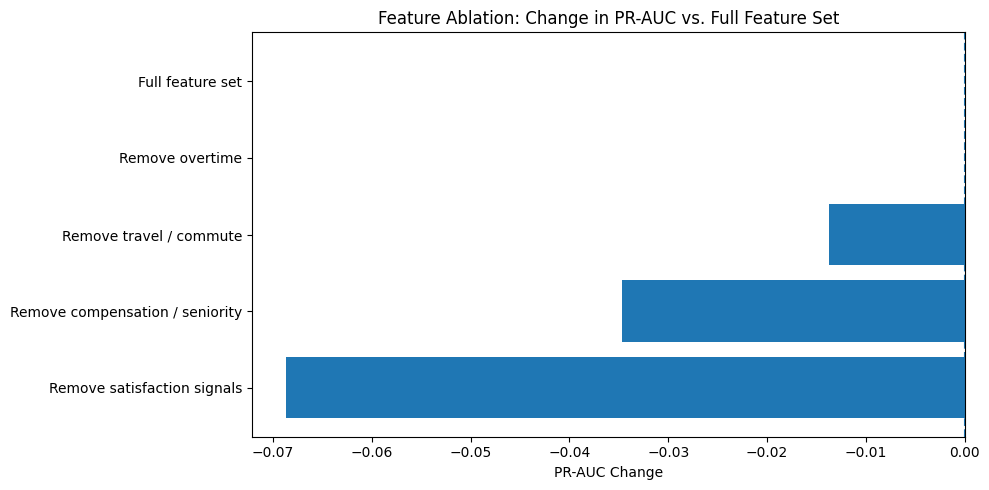

In [49]:
# ============================================================
# 18 — FEATURE ABLATION PLOT + MLFLOW ARTIFACT
# ============================================================

plot_ablation = ablation_df.sort_values("pr_auc_change_vs_full")

plt.figure(figsize=(10, 5))
plt.barh(
    plot_ablation["experiment"],
    plot_ablation["pr_auc_change_vs_full"],
)
plt.axvline(0, linestyle="--")
plt.title("Feature Ablation: Change in PR-AUC vs. Full Feature Set")
plt.xlabel("PR-AUC Change")
plt.ylabel("")
plt.tight_layout()

ablation_plot_path = ARTIFACT_DIR / "feature_ablation_pr_auc.png"
plt.savefig(ablation_plot_path, dpi=160)
plt.show()

with mlflow.start_run(run_name="xgboost_feature_ablation_study"):
    mlflow.log_params({
        "model_name": "XGBoost",
        "validation_strategy": "Stratified 5-fold CV on training data",
        "selection_metric": "PR-AUC",
    })
    mlflow.log_artifact(str(ablation_csv_path))
    mlflow.log_artifact(str(ablation_plot_path))

In [56]:
# ============================================================
# SAVE FINAL V3 MODEL, METRICS, AND ARTIFACTS
# ============================================================

from pathlib import Path
import json
import joblib
import mlflow

MODEL_VERSION = "v3_engineered_without_raw_overtime"

# Versioned folders
V3_DIR = Path("attrishield_versions") / MODEL_VERSION
V3_MODEL_DIR = V3_DIR / "model"
V3_ARTIFACT_DIR = V3_DIR / "artifacts"

V3_MODEL_DIR.mkdir(parents=True, exist_ok=True)
V3_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# 1. Save the full fitted pipeline:
# preprocessing + SMOTE configuration + XGBoost model
v3_model_path = V3_MODEL_DIR / "attrishield_pipeline_v3.joblib"
joblib.dump(final_pipeline, v3_model_path)

# 2. Save reproducibility and decision metadata
v3_metadata = {
    "model_version": MODEL_VERSION,
    "feature_version": "engineered_features_without_raw_overtime",
    "raw_overtime_retained": False,
    "seed": int(SEED),
    "test_size": float(TEST_SIZE),
    "cv_folds": 5,
    "model_name": "XGBoost",
    "selected_threshold": float(BEST_THRESHOLD),
    "threshold_selection_method": "5-fold out-of-fold training predictions",
    "business_cost_assumption": {
        "false_negative_cost": int(FALSE_NEGATIVE_COST),
        "false_positive_cost": int(FALSE_POSITIVE_COST),
    },
    "cv_metrics": {
        "accuracy_mean": 0.875849,
        "precision_mean": 0.723728,
        "recall_mean": 0.389474,
        "f1_mean": 0.498753,
        "roc_auc_mean": 0.816203,
        "pr_auc_mean": 0.625005,
    },
    "test_metrics": {
        "accuracy": float(final_metrics["accuracy"]),
        "precision": float(final_metrics["precision"]),
        "recall": float(final_metrics["recall"]),
        "f1": float(final_metrics["f1"]),
        "roc_auc": float(final_metrics["roc_auc"]),
        "pr_auc": float(final_metrics["pr_auc"]),
        "brier_score": float(brier),
        "expected_calibration_error": float(ece),
    },
    "feature_engineering": [
        "IncomePerJobLevel",
        "PromotionStagnationRatio",
        "ManagerTenureRatio",
        "RoleTenureRatio",
        "OverTimeBinary",
        "CommuteOvertimeBurden",
        "EarlyCareerFlag",
    ],
}

v3_metadata_path = V3_DIR / "model_metadata_v3.json"
with open(v3_metadata_path, "w") as f:
    json.dump(v3_metadata, f, indent=2)

print(f"Saved V3 pipeline: {v3_model_path}")
print(f"Saved V3 metadata: {v3_metadata_path}")

Saved V3 pipeline: attrishield_versions/v3_engineered_without_raw_overtime/model/attrishield_pipeline_v3.joblib
Saved V3 metadata: attrishield_versions/v3_engineered_without_raw_overtime/model_metadata_v3.json


In [57]:
# ============================================================
# COPY V3 ARTIFACTS INTO THE VERSIONED FOLDER
# ============================================================

import shutil

artifact_files = [
    "threshold_optimization.png",
    "threshold_optimization.csv",
    "final_confusion_matrix.png",
    "final_roc_curve.png",
    "final_precision_recall_curve.png",
    "final_test_metrics.json",
    "calibration_curve.png",
    "calibration_bins.csv",
    "calibration_metrics.json",
    "shap_summary.png",
    "shap_global_importance.csv",
    "shap_waterfall_high_risk_employee.png",
    "high_risk_employee_profile.csv",
    "error_outcome_groups.png",
    "error_analysis_all_test_cases.csv",
    "false_positives.csv",
    "false_negatives.csv",
    "false_negative_vs_true_positive_summary.csv",
    "feature_ablation_study.csv",
    "feature_ablation_pr_auc.png",
]

for filename in artifact_files:
    source = ARTIFACT_DIR / filename
    destination = V3_ARTIFACT_DIR / filename

    if source.exists():
        shutil.copy2(source, destination)
        print(f"Copied: {filename}")
    else:
        print(f"Skipped (not found): {filename}")

Skipped (not found): threshold_optimization.png
Skipped (not found): threshold_optimization.csv
Skipped (not found): final_confusion_matrix.png
Skipped (not found): final_roc_curve.png
Skipped (not found): final_precision_recall_curve.png
Skipped (not found): final_test_metrics.json
Copied: calibration_curve.png
Copied: calibration_bins.csv
Copied: calibration_metrics.json
Copied: shap_summary.png
Copied: shap_global_importance.csv
Copied: shap_waterfall_high_risk_employee.png
Copied: high_risk_employee_profile.csv
Copied: error_outcome_groups.png
Copied: error_analysis_all_test_cases.csv
Copied: false_positives.csv
Copied: false_negatives.csv
Copied: false_negative_vs_true_positive_summary.csv
Copied: feature_ablation_study.csv
Copied: feature_ablation_pr_auc.png


In [58]:
# ============================================================
# REGISTER FINAL V3 RELEASE IN MLFLOW
# ============================================================

mlflow.set_experiment("AttriShield_Model_Versions")

with mlflow.start_run(run_name="V3_FINAL_engineered_without_raw_overtime"):
    mlflow.log_params({
        "model_version": MODEL_VERSION,
        "feature_version": "engineered_without_raw_overtime",
        "raw_overtime_retained": False,
        "seed": SEED,
        "test_size": TEST_SIZE,
        "cv_folds": 5,
        "model_name": "XGBoost",
        "selected_threshold": BEST_THRESHOLD,
        "threshold_selection_method": "OOF_cost_sensitive",
        "false_negative_cost": FALSE_NEGATIVE_COST,
        "false_positive_cost": FALSE_POSITIVE_COST,
    })

    mlflow.log_metrics({
        "cv_accuracy_mean": 0.875849,
        "cv_precision_mean": 0.723728,
        "cv_recall_mean": 0.389474,
        "cv_f1_mean": 0.498753,
        "cv_roc_auc_mean": 0.816203,
        "cv_pr_auc_mean": 0.625005,
        "test_accuracy": final_metrics["accuracy"],
        "test_precision": final_metrics["precision"],
        "test_recall": final_metrics["recall"],
        "test_f1": final_metrics["f1"],
        "test_roc_auc": final_metrics["roc_auc"],
        "test_pr_auc": final_metrics["pr_auc"],
        "test_brier_score": brier,
        "test_ece": ece,
    })

    mlflow.log_artifact(str(v3_model_path), artifact_path="model")
    mlflow.log_artifact(str(v3_metadata_path), artifact_path="metadata")

    for artifact_file in V3_ARTIFACT_DIR.iterdir():
        if artifact_file.is_file():
            mlflow.log_artifact(str(artifact_file), artifact_path="artifacts")

print("V3 final release saved and logged to MLflow.")

2026/07/06 09:19:06 INFO mlflow.tracking.fluent: Experiment with name 'AttriShield_Model_Versions' does not exist. Creating a new experiment.


V3 final release saved and logged to MLflow.


In [50]:
# ============================================================
# CONTROLLED V2 COMPARISON — engineered features + raw OverTime
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

# If df_raw is not available, uncomment and update the path:
df_raw = pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")

V2_ARTIFACT_DIR = Path("artifacts_v2_controlled")
V2_ARTIFACT_DIR.mkdir(exist_ok=True)

# Start from the same raw source, not the already-modified V3 dataframe.
df_v2 = df_raw.copy()

# Remove only constant / identifier columns.
drop_columns = ["EmployeeNumber", "EmployeeCount", "Over18", "StandardHours"]
df_v2 = df_v2.drop(columns=drop_columns, errors="ignore")

# Binary target
y_v2 = (df_v2["Attrition"] == "Yes").astype(int)
X_v2 = df_v2.drop(columns="Attrition").copy()

# V2 engineered features — retain the raw categorical OverTime column.
X_v2["IncomePerJobLevel"] = X_v2["MonthlyIncome"] / X_v2["JobLevel"].clip(lower=1)
X_v2["PromotionStagnationRatio"] = (
    X_v2["YearsSinceLastPromotion"] / (X_v2["YearsAtCompany"] + 1)
)
X_v2["ManagerTenureRatio"] = (
    X_v2["YearsWithCurrManager"] / (X_v2["YearsAtCompany"] + 1)
)
X_v2["RoleTenureRatio"] = (
    X_v2["YearsInCurrentRole"] / (X_v2["YearsAtCompany"] + 1)
)
X_v2["OverTimeBinary"] = (X_v2["OverTime"] == "Yes").astype(int)
X_v2["CommuteOvertimeBurden"] = (
    X_v2["DistanceFromHome"] * X_v2["OverTimeBinary"]
)
X_v2["EarlyCareerFlag"] = (X_v2["YearsAtCompany"] <= 2).astype(int)

assert "OverTime" in X_v2.columns, "V2 must retain raw OverTime."
print("V2 shape:", X_v2.shape)
print("Raw OverTime retained:", "OverTime" in X_v2.columns)

V2 shape: (1470, 37)
Raw OverTime retained: True


In [51]:
from sklearn.model_selection import train_test_split, StratifiedKFold

SEED = 42
TEST_SIZE = 0.20

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2,
    y_v2,
    test_size=TEST_SIZE,
    stratify=y_v2,
    random_state=SEED,
)

cv_v2 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)

print("V2 train distribution:", y_train_v2.value_counts().to_dict())
print("V2 test distribution:", y_test_v2.value_counts().to_dict())

V2 train distribution: {0: 986, 1: 190}
V2 test distribution: {0: 247, 1: 47}


In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import xgboost as xgb

numeric_features_v2 = X_train_v2.select_dtypes(
    include=["int64", "float64", "bool"]
).columns.tolist()

categorical_features_v2 = X_train_v2.select_dtypes(
    include=["object", "category"]
).columns.tolist()

preprocessor_v2 = ColumnTransformer(
    transformers=[
        (
            "num",
            SklearnPipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_features_v2,
        ),
        (
            "cat",
            SklearnPipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categorical_features_v2,
        ),
    ],
    verbose_feature_names_out=False,
)

xgb_v2 = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=SEED,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=2,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=1.0,
    n_jobs=-1,
)

pipeline_v2 = ImbPipeline(steps=[
    ("preprocessor", preprocessor_v2),
    ("smote", SMOTE(random_state=SEED, k_neighbors=5)),
    ("model", xgb_v2),
])

In [53]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import roc_auc_score, average_precision_score
import json

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}

v2_cv = cross_validate(
    pipeline_v2,
    X_train_v2,
    y_train_v2,
    cv=cv_v2,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False,
)

v2_summary = {
    metric.replace("test_", ""): {
        "mean": float(np.mean(values)),
        "std": float(np.std(values)),
    }
    for metric, values in v2_cv.items()
    if metric.startswith("test_")
}

v2_summary_df = pd.DataFrame({
    metric: [values["mean"], values["std"]]
    for metric, values in v2_summary.items()
}, index=["mean", "std"]).T

display(v2_summary_df)

# Fit once on training data; use the same untouched test partition as V3.
pipeline_v2.fit(X_train_v2, y_train_v2)
v2_test_proba = pipeline_v2.predict_proba(X_test_v2)[:, 1]

v2_test_ranking = {
    "roc_auc": roc_auc_score(y_test_v2, v2_test_proba),
    "pr_auc": average_precision_score(y_test_v2, v2_test_proba),
}

print("\nV2 untouched-test ranking metrics:")
for name, value in v2_test_ranking.items():
    print(f"{name}: {value:.4f}")

with open(V2_ARTIFACT_DIR / "controlled_v2_results.json", "w") as f:
    json.dump(
        {
            "feature_version": "V2_engineered_with_raw_overtime",
            "cv": v2_summary,
            "test_ranking": v2_test_ranking,
        },
        f,
        indent=2,
    )

,mean,std
accuracy,0.878402,0.019696
precision,0.730433,0.112258
recall,0.389474,0.099026
f1,0.503452,0.103046
roc_auc,0.818873,0.033426
pr_auc,0.620570,0.073473



V2 untouched-test ranking metrics:
roc_auc: 0.7954
pr_auc: 0.5231


In [54]:
import mlflow

mlflow.set_experiment("AttriShield_Controlled_Feature_Comparison")

with mlflow.start_run(run_name="V2_engineered_with_raw_overtime"):
    mlflow.log_params({
        "feature_version": "V2_engineered_with_raw_overtime",
        "raw_overtime_retained": True,
        "seed": SEED,
        "test_size": TEST_SIZE,
        "cv_folds": 5,
        "smote_inside_cv": True,
    })

    mlflow.log_metrics({
        f"cv_{metric}_mean": values["mean"]
        for metric, values in v2_summary.items()
    })
    mlflow.log_metrics({
        f"cv_{metric}_std": values["std"]
        for metric, values in v2_summary.items()
    })
    mlflow.log_metrics({
        f"test_{metric}": value
        for metric, value in v2_test_ranking.items()
    })

    mlflow.log_artifact(str(V2_ARTIFACT_DIR / "controlled_v2_results.json"))

2026/07/06 09:11:05 INFO mlflow.tracking.fluent: Experiment with name 'AttriShield_Controlled_Feature_Comparison' does not exist. Creating a new experiment.


In [55]:
v3_reference = {
    "cv_pr_auc_mean": 0.625005,
    "cv_pr_auc_std": 0.062895,
    "cv_recall_mean": 0.389474,
    "cv_f1_mean": 0.498753,
    "test_roc_auc": 0.8058,
    "test_pr_auc": 0.5440,
}

comparison = pd.DataFrame([
    {
        "version": "V2: engineered + raw OverTime",
        "cv_pr_auc_mean": v2_summary["pr_auc"]["mean"],
        "cv_pr_auc_std": v2_summary["pr_auc"]["std"],
        "cv_recall_mean": v2_summary["recall"]["mean"],
        "cv_f1_mean": v2_summary["f1"]["mean"],
        "test_roc_auc": v2_test_ranking["roc_auc"],
        "test_pr_auc": v2_test_ranking["pr_auc"],
    },
    {
        "version": "V3: engineered - raw OverTime",
        **v3_reference,
    },
])

display(comparison)

,version,cv_pr_auc_mean,cv_pr_auc_std,cv_recall_mean,cv_f1_mean,test_roc_auc,test_pr_auc
0,V2: engineered + raw OverTime,0.620570,0.073473,0.389474,0.503452,0.795417,0.523143
1,V3: engineered - raw OverTime,0.625005,0.062895,0.389474,0.498753,0.805800,0.544000


In [59]:
with mlflow.start_run(run_name="V3_FINAL_engineered_without_raw_overtime"):
    mlflow.set_tags({
        "project": "AttriShield",
        "stage": "final",
        "problem_type": "binary_classification",
        "domain": "employee_attrition",
        "selection_metric": "PR-AUC",
        "deployment_status": "candidate_for_deployment",
    })

In [60]:
!mlflow ui --backend-store-uri sqlite:////content/mlflow.db --host 0.0.0.0 --port 5000

Registry store URI not provided. Using backend store URI.
[MLflow] Security middleware enabled with default settings (localhost-only). To allow connections from other hosts, use --host 0.0.0.0 and configure --allowed-hosts and --cors-allowed-origins.
/usr/local/lib/python3.12/dist-packages/mlflow/server/fastapi_app.py:17: StarletteDeprecationWarning: starlette.middleware.wsgi is deprecated and will be removed in a future release. Please refer to https://github.com/abersheeran/a2wsgi as a replacement.
  from starlette.middleware.wsgi import WSGIResponder, build_environ
2026/07/06 09:22:35 INFO:     Uvicorn running on http://0.0.0.0:5000 (Press CTRL+C to quit)
2026/07/06 09:22:35 INFO:     Started parent process [22064]
/usr/local/lib/python3.12/dist-packages/mlflow/server/fastapi_app.py:17: StarletteDeprecationWarning: starlette.middleware.wsgi is deprecated and will be removed in a future release. Please refer to https://github.com/abersheeran/a2wsgi as a replacement.
  from starlette.

In [61]:
from google.colab import output

output.serve_kernel_port_as_window(5000)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [62]:
import mlflow
from mlflow.tracking import MlflowClient

# Must match the database URI you used earlier.
mlflow.set_tracking_uri("sqlite:////content/mlflow.db")

client = MlflowClient()

for experiment in client.search_experiments():
    print(f"\nExperiment: {experiment.name}")
    print(f"Experiment ID: {experiment.experiment_id}")

    runs = client.search_runs(
        experiment_ids=[experiment.experiment_id],
        order_by=["attributes.start_time DESC"],
    )

    for run in runs:
        print(f"  Run: {run.info.run_name}")
        print(f"  Run ID: {run.info.run_id}")
        print(f"  Status: {run.info.status}")
        print("  Metrics:", run.data.metrics)
        print("  Params:", run.data.params)


Experiment: AttriShield_Model_Versions
Experiment ID: 3
  Run: V3_FINAL_engineered_without_raw_overtime
  Run ID: 5eec63505251436f88108de1610247e0
  Status: FINISHED
  Metrics: {}
  Params: {}
  Run: V3_FINAL_engineered_without_raw_overtime
  Run ID: d74445ed77c547d49eef419ae7892891
  Status: FINISHED
  Metrics: {'cv_accuracy_mean': 0.875849, 'cv_precision_mean': 0.723728, 'cv_recall_mean': 0.389474, 'cv_f1_mean': 0.498753, 'cv_roc_auc_mean': 0.816203, 'cv_pr_auc_mean': 0.625005, 'test_accuracy': 0.7789115646258503, 'test_precision': 0.38461538461538464, 'test_recall': 0.6382978723404256, 'test_f1': 0.48, 'test_roc_auc': 0.8057541562580756, 'test_pr_auc': 0.5439645554460173, 'test_brier_score': 0.10486069797708254, 'test_ece': 0.05637405240008621}
  Params: {'model_version': 'v3_engineered_without_raw_overtime', 'feature_version': 'engineered_without_raw_overtime', 'raw_overtime_retained': 'False', 'seed': '42', 'test_size': '0.2', 'cv_folds': '5', 'model_name': 'XGBoost', 'selected_t

In [63]:
import shutil
from google.colab import files

shutil.make_archive(
    "attrishield_v3_release",
    "zip",
    "attrishield_versions/v3_engineered_without_raw_overtime",
)

files.download("attrishield_v3_release.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [64]:
from google.colab import files

files.download(
    "attrishield_versions/v3_engineered_without_raw_overtime/model/attrishield_pipeline_v3.joblib"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [67]:
%%writefile app.py
import json
import time
from datetime import datetime, timezone
from pathlib import Path

import joblib
import pandas as pd
import streamlit as st


# ============================================================
# CONFIGURATION
# ============================================================
MODEL_PATH = Path("models/attrishield_pipeline_v3.joblib")
METADATA_PATH = Path("models/model_metadata_v3.json")

LOG_DIR = Path("logs")
LOG_DIR.mkdir(exist_ok=True)

PREDICTION_LOG_PATH = LOG_DIR / "prediction_log.csv"
DEFAULT_THRESHOLD = 0.15


# ============================================================
# STREAMLIT PAGE
# ============================================================
st.set_page_config(
    page_title="AttriShield V3",
    page_icon="🛡️",
    layout="wide",
)


# ============================================================
# LOAD MODEL AND METADATA
# ============================================================
@st.cache_resource
def load_artifacts():
    if not MODEL_PATH.exists():
        raise FileNotFoundError(
            f"Model not found: {MODEL_PATH}\n\n"
            "Create a folder named 'models' and place "
            "'attrishield_pipeline_v3.joblib' inside it."
        )

    model = joblib.load(MODEL_PATH)

    metadata = {}

    if METADATA_PATH.exists():
        with open(METADATA_PATH, "r") as file:
            metadata = json.load(file)

    return model, metadata


# ============================================================
# V3 FEATURE ENGINEERING
# IMPORTANT:
# V3 uses engineered overtime features.
# Raw 'OverTime' is removed before model inference.
# ============================================================
def add_v3_features(df):
    data = df.copy()

    required_columns = [
        "MonthlyIncome",
        "JobLevel",
        "YearsSinceLastPromotion",
        "YearsAtCompany",
        "YearsWithCurrManager",
        "YearsInCurrentRole",
        "DistanceFromHome",
        "OverTime",
    ]

    missing_columns = [
        column for column in required_columns
        if column not in data.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Missing required columns: {missing_columns}"
        )

    data["IncomePerJobLevel"] = (
        data["MonthlyIncome"] /
        data["JobLevel"].clip(lower=1)
    )

    data["PromotionStagnationRatio"] = (
        data["YearsSinceLastPromotion"] /
        (data["YearsAtCompany"] + 1)
    )

    data["ManagerTenureRatio"] = (
        data["YearsWithCurrManager"] /
        (data["YearsAtCompany"] + 1)
    )

    data["RoleTenureRatio"] = (
        data["YearsInCurrentRole"] /
        (data["YearsAtCompany"] + 1)
    )

    data["OverTimeBinary"] = (
        data["OverTime"]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("yes")
        .astype(int)
    )

    data["CommuteOvertimeBurden"] = (
        data["DistanceFromHome"] *
        data["OverTimeBinary"]
    )

    data["EarlyCareerFlag"] = (
        data["YearsAtCompany"] <= 2
    ).astype(int)

    # V3 intentionally excludes raw OverTime.
    data = data.drop(columns=["OverTime"], errors="ignore")

    return data


# ============================================================
# PREDICTION LOGGING
# Logs only model metadata, not personal employee details.
# ============================================================
def log_prediction(probability, decision, latency_ms, mode, threshold):
    log_row = pd.DataFrame([
        {
            "timestamp_utc": datetime.now(timezone.utc).isoformat(),
            "mode": mode,
            "threshold": round(float(threshold), 4),
            "attrition_probability": round(float(probability), 6),
            "review_recommended": int(decision),
            "latency_ms": round(float(latency_ms), 2),
        }
    ])

    write_header = not PREDICTION_LOG_PATH.exists()

    log_row.to_csv(
        PREDICTION_LOG_PATH,
        mode="a",
        header=write_header,
        index=False,
    )


# ============================================================
# SIDEBAR INPUT FORM
# These are raw IBM HR Attrition dataset fields.
# ============================================================
def get_employee_input():
    st.sidebar.header("Employee Profile")

    age = st.sidebar.number_input(
        "Age",
        min_value=18,
        max_value=60,
        value=30,
    )

    business_travel = st.sidebar.selectbox(
        "Business Travel",
        ["Non-Travel", "Travel_Rarely", "Travel_Frequently"],
    )

    daily_rate = st.sidebar.number_input(
        "Daily Rate",
        min_value=100,
        max_value=1500,
        value=800,
    )

    department = st.sidebar.selectbox(
        "Department",
        ["Sales", "Research & Development", "Human Resources"],
    )

    distance_from_home = st.sidebar.number_input(
        "Distance From Home",
        min_value=1,
        max_value=30,
        value=10,
    )

    education = st.sidebar.selectbox(
        "Education Level",
        [1, 2, 3, 4, 5],
        index=2,
    )

    education_field = st.sidebar.selectbox(
        "Education Field",
        [
            "Life Sciences",
            "Medical",
            "Marketing",
            "Technical Degree",
            "Other",
            "Human Resources",
        ],
    )

    environment_satisfaction = st.sidebar.selectbox(
        "Environment Satisfaction",
        [1, 2, 3, 4],
        index=2,
    )

    gender = st.sidebar.selectbox(
        "Gender",
        ["Female", "Male"],
    )

    hourly_rate = st.sidebar.number_input(
        "Hourly Rate",
        min_value=30,
        max_value=100,
        value=65,
    )

    job_involvement = st.sidebar.selectbox(
        "Job Involvement",
        [1, 2, 3, 4],
        index=2,
    )

    job_level = st.sidebar.selectbox(
        "Job Level",
        [1, 2, 3, 4, 5],
        index=1,
    )

    job_role = st.sidebar.selectbox(
        "Job Role",
        [
            "Sales Executive",
            "Research Scientist",
            "Laboratory Technician",
            "Manufacturing Director",
            "Healthcare Representative",
            "Manager",
            "Sales Representative",
            "Research Director",
            "Human Resources",
        ],
    )

    job_satisfaction = st.sidebar.selectbox(
        "Job Satisfaction",
        [1, 2, 3, 4],
        index=2,
    )

    marital_status = st.sidebar.selectbox(
        "Marital Status",
        ["Single", "Married", "Divorced"],
    )

    monthly_income = st.sidebar.number_input(
        "Monthly Income",
        min_value=1000,
        max_value=30000,
        value=8000,
    )

    monthly_rate = st.sidebar.number_input(
        "Monthly Rate",
        min_value=2000,
        max_value=30000,
        value=15000,
    )

    num_companies_worked = st.sidebar.number_input(
        "Number of Companies Worked",
        min_value=0,
        max_value=10,
        value=1,
    )

    overtime = st.sidebar.selectbox(
        "OverTime",
        ["No", "Yes"],
    )

    percent_salary_hike = st.sidebar.number_input(
        "Percent Salary Hike",
        min_value=10,
        max_value=30,
        value=15,
    )

    performance_rating = st.sidebar.selectbox(
        "Performance Rating",
        [3, 4],
    )

    relationship_satisfaction = st.sidebar.selectbox(
        "Relationship Satisfaction",
        [1, 2, 3, 4],
        index=2,
    )

    stock_option_level = st.sidebar.selectbox(
        "Stock Option Level",
        [0, 1, 2, 3],
        index=1,
    )

    total_working_years = st.sidebar.number_input(
        "Total Working Years",
        min_value=0,
        max_value=40,
        value=5,
    )

    training_times_last_year = st.sidebar.number_input(
        "Training Times Last Year",
        min_value=0,
        max_value=10,
        value=2,
    )

    work_life_balance = st.sidebar.selectbox(
        "Work Life Balance",
        [1, 2, 3, 4],
        index=2,
    )

    years_at_company = st.sidebar.number_input(
        "Years At Company",
        min_value=0,
        max_value=40,
        value=3,
    )

    years_in_current_role = st.sidebar.number_input(
        "Years In Current Role",
        min_value=0,
        max_value=40,
        value=2,
    )

    years_since_last_promotion = st.sidebar.number_input(
        "Years Since Last Promotion",
        min_value=0,
        max_value=40,
        value=1,
    )

    years_with_curr_manager = st.sidebar.number_input(
        "Years With Current Manager",
        min_value=0,
        max_value=40,
        value=2,
    )

    return {
        "Age": age,
        "BusinessTravel": business_travel,
        "DailyRate": daily_rate,
        "Department": department,
        "DistanceFromHome": distance_from_home,
        "Education": education,
        "EducationField": education_field,
        "EnvironmentSatisfaction": environment_satisfaction,
        "Gender": gender,
        "HourlyRate": hourly_rate,
        "JobInvolvement": job_involvement,
        "JobLevel": job_level,
        "JobRole": job_role,
        "JobSatisfaction": job_satisfaction,
        "MaritalStatus": marital_status,
        "MonthlyIncome": monthly_income,
        "MonthlyRate": monthly_rate,
        "NumCompaniesWorked": num_companies_worked,
        "OverTime": overtime,
        "PercentSalaryHike": percent_salary_hike,
        "PerformanceRating": performance_rating,
        "RelationshipSatisfaction": relationship_satisfaction,
        "StockOptionLevel": stock_option_level,
        "TotalWorkingYears": total_working_years,
        "TrainingTimesLastYear": training_times_last_year,
        "WorkLifeBalance": work_life_balance,
        "YearsAtCompany": years_at_company,
        "YearsInCurrentRole": years_in_current_role,
        "YearsSinceLastPromotion": years_since_last_promotion,
        "YearsWithCurrManager": years_with_curr_manager,
    }


# ============================================================
# DISPLAY MODEL CONTEXT
# ============================================================
def show_model_context(metadata, threshold):
    with st.expander("Model details and operating considerations"):
        st.markdown(
            f"""
            **Model:** XGBoost
            **Version:** V3 engineered features without raw `OverTime`
            **Operating threshold:** {threshold:.2f}
            **Selection metric:** PR-AUC for imbalanced attrition prediction

            **Final V3 results**
            - 5-fold CV PR-AUC: 0.625 ± 0.063
            - Untouched-test ROC-AUC: 0.806
            - Untouched-test PR-AUC: 0.544
            - Untouched-test recall: 0.638
            - Brier score: 0.105
            - Expected Calibration Error: 0.056

            **Decision policy**
            The 0.15 threshold prioritizes recall because missed attrition cases
            were treated as more costly than unnecessary reviews.

            **Responsible-use note**
            This is a portfolio decision-support prototype. It should not be used
            for automated employment decisions. Predictions should be reviewed by
            qualified HR professionals with appropriate fairness, privacy, and
            policy controls.
            """
        )

        if metadata:
            st.caption(
                f"Saved model version: "
                f"{metadata.get('model_version', 'V3')}"
            )


# ============================================================
# INDIVIDUAL PREDICTION MODE
# ============================================================
def individual_prediction_mode(model, threshold):
    st.header("Individual Attrition Risk Assessment")

    employee_data = get_employee_input()

    if st.sidebar.button("Predict Attrition Risk", use_container_width=True):
        try:
            raw_df = pd.DataFrame([employee_data])
            model_input = add_v3_features(raw_df)

            start_time = time.perf_counter()

            probability = float(
                model.predict_proba(model_input)[:, 1][0]
            )

            latency_ms = (
                time.perf_counter() - start_time
            ) * 1000

            decision = int(probability >= threshold)

            log_prediction(
                probability=probability,
                decision=decision,
                latency_ms=latency_ms,
                mode="individual",
                threshold=threshold,
            )

            col1, col2, col3 = st.columns(3)

            col1.metric(
                "Attrition Risk Probability",
                f"{probability:.1%}",
            )

            col2.metric(
                "Decision Threshold",
                f"{threshold:.0%}",
            )

            col3.metric(
                "Inference Latency",
                f"{latency_ms:.1f} ms",
            )

            if decision == 1:
                st.warning(
                    "Review recommended. The predicted risk exceeds the "
                    "cost-sensitive operating threshold."
                )
            else:
                st.success(
                    "No immediate review recommended at the selected threshold."
                )

            st.progress(int(probability * 100))

            st.subheader("V3 Engineered Features")

            engineered_columns = [
                "IncomePerJobLevel",
                "PromotionStagnationRatio",
                "ManagerTenureRatio",
                "RoleTenureRatio",
                "OverTimeBinary",
                "CommuteOvertimeBurden",
                "EarlyCareerFlag",
            ]

            st.dataframe(
                model_input[engineered_columns]
                .T
                .rename(columns={0: "Value"}),
                use_container_width=True,
            )

        except Exception as error:
            st.error(f"Prediction failed: {error}")


# ============================================================
# BATCH PREDICTION MODE
# ============================================================
def batch_prediction_mode(model, threshold):
    st.header("Batch Attrition Risk Screening")

    st.caption(
        "Upload a CSV containing raw IBM HR Attrition-style columns. "
        "The app creates V3 engineered features automatically."
    )

    uploaded_file = st.file_uploader(
        "Upload CSV",
        type=["csv"],
    )

    if uploaded_file is not None:
        try:
            raw_df = pd.read_csv(uploaded_file)

            model_input = add_v3_features(raw_df)

            start_time = time.perf_counter()

            probabilities = model.predict_proba(model_input)[:, 1]

            total_latency_ms = (
                time.perf_counter() - start_time
            ) * 1000

            output_df = raw_df.copy()

            output_df["attrition_risk_probability"] = (
                probabilities.round(4)
            )

            output_df["review_recommended"] = (
                probabilities >= threshold
            ).astype(int)

            output_df["decision_threshold"] = threshold

            average_latency = total_latency_ms / max(len(output_df), 1)

            for probability in probabilities:
                log_prediction(
                    probability=float(probability),
                    decision=int(probability >= threshold),
                    latency_ms=average_latency,
                    mode="batch",
                    threshold=threshold,
                )

            col1, col2, col3 = st.columns(3)

            col1.metric(
                "Employees Screened",
                len(output_df),
            )

            col2.metric(
                "Reviews Recommended",
                int(output_df["review_recommended"].sum()),
            )

            col3.metric(
                "Total Batch Latency",
                f"{total_latency_ms:.1f} ms",
            )

            st.dataframe(
                output_df.head(25),
                use_container_width=True,
            )

            csv_data = output_df.to_csv(index=False).encode("utf-8")

            st.download_button(
                label="Download Scored CSV",
                data=csv_data,
                file_name="attrishield_v3_predictions.csv",
                mime="text/csv",
            )

        except Exception as error:
            st.error(f"Batch prediction failed: {error}")


# ============================================================
# MONITORING MODE
# ============================================================
def monitoring_mode():
    st.header("Inference Monitoring")

    st.caption(
        "A lightweight local monitoring view based on prediction metadata. "
        "No employee-identifying input fields are logged."
    )

    if not PREDICTION_LOG_PATH.exists():
        st.info(
            "No prediction logs found yet. Run an individual or batch "
            "prediction first."
        )
        return

    logs = pd.read_csv(PREDICTION_LOG_PATH)

    if logs.empty:
        st.info("Prediction log is empty.")
        return

    logs["timestamp_utc"] = pd.to_datetime(
        logs["timestamp_utc"],
        errors="coerce",
    )

    col1, col2, col3 = st.columns(3)

    col1.metric(
        "Predictions Logged",
        len(logs),
    )

    col2.metric(
        "Review Rate",
        f"{logs['review_recommended'].mean():.1%}",
    )

    col3.metric(
        "Median Latency",
        f"{logs['latency_ms'].median():.1f} ms",
    )

    st.subheader("Prediction Probability Distribution")

    probability_bins = (
        logs["attrition_probability"]
        .round(1)
        .value_counts()
        .sort_index()
    )

    st.bar_chart(probability_bins)

    st.subheader("Recent Prediction Metadata")

    st.dataframe(
        logs.sort_values(
            "timestamp_utc",
            ascending=False,
        ).head(50),
        use_container_width=True,
    )


# ============================================================
# MAIN APPLICATION
# ============================================================
def main():
    st.title("🛡️ AttriShield V3")

    st.caption(
        "Applied ML decision-support prototype for employee attrition-risk screening"
    )

    try:
        model, metadata = load_artifacts()

    except Exception as error:
        st.error(str(error))
        st.stop()

    threshold = float(
        metadata.get(
            "selected_threshold",
            DEFAULT_THRESHOLD,
        )
    )

    show_model_context(metadata, threshold)

    mode = st.sidebar.radio(
        "Application Mode",
        [
            "Individual Prediction",
            "Batch Prediction",
            "Monitoring",
        ],
    )

    if mode == "Individual Prediction":
        individual_prediction_mode(model, threshold)

    elif mode == "Batch Prediction":
        batch_prediction_mode(model, threshold)

    else:
        monitoring_mode()


if __name__ == "__main__":
    main()

Writing app.py


In [68]:
!mkdir -p models logs

!cp attrishield_versions/v3_engineered_without_raw_overtime/model/attrishield_pipeline_v3.joblib models/

!cp attrishield_versions/v3_engineered_without_raw_overtime/model_metadata_v3.json models/

In [69]:
!pip install streamlit pandas joblib scikit-learn imbalanced-learn xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 39.6 MB/s eta 0:00:00


In [ ]:
!streamlit run app.py --server.port 8501 &



2026-07-06 09:48:25.260 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.125.209.136:8501

2026-07-06 09:48:57.956 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-07-06 09:50:03.650 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-07-06 09:51:19.229 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-07-06 10:31:11.517 Plea

In [73]:
!pip install pyngrok

In [74]:
from pyngrok import ngrok

ngrok.set_auth_token("2qcju9mGjXzP8QTdRyPXYzaPary_7C3yG6WE7AzidDqTbQcfo")

In [75]:
from pyngrok import ngrok

ngrok.kill()  # closes any old tunnels

public_url = ngrok.connect(8501)
print("Open this URL:", public_url)

Open this URL: NgrokTunnel: "https://59a7-34-125-209-136.ngrok-free.app" -> "http://localhost:8501"
